## City wide validation 

This notebook validates mean velocites on city level

In [40]:
from pathlib import Path
import pyarrow.parquet as pq
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import shapely
import builtins
from shapely.geometry import box

## Directory setup

In [2]:
augmenterra_data_dir = Path("/home/lukas/projects/ADUCAT/data/Augmenterra/processed")
own_insar_data_dir = Path("/home/lukas/projects/ADUCAT/data/final_outputs")
egms_data_dir = Path("/home/lukas/projects/ADUCAT/data/EGMS/vienna/processed")

print("Reference data directory:", augmenterra_data_dir)
print("Own processed data directory:", own_insar_data_dir)
print("EGMS data directory:", egms_data_dir)

Reference data directory: /home/lukas/projects/ADUCAT/data/Augmenterra/processed
Own processed data directory: /home/lukas/projects/ADUCAT/data/final_outputs
EGMS data directory: /home/lukas/projects/ADUCAT/data/EGMS/vienna/processed


In [3]:
orbit_direction = "ASC"
orbit = "073"


ref_augmenterra_file = Path(augmenterra_data_dir, f"VIENNA_TUNNELLING_velocity_{orbit_direction}.parquet")
print("Augmenterra reference data file:", ref_augmenterra_file)

ref_egms_file = Path(egms_data_dir, f"EGMS_{orbit}_2020_2024.parquet")
print("EGMS reference data file:", ref_egms_file)

processed_data_file = Path(own_insar_data_dir, "download-isce2-new-xc6vs_result2.parquet")
print("Own processed data file:", processed_data_file)

aoi_city_file = Path("/home/lukas/projects/ADUCAT/data/AOI/Projektgebiet_ADUCAT-AOI.gpkg")
print("AOI city file:", aoi_city_file)


Augmenterra reference data file: /home/lukas/projects/ADUCAT/data/Augmenterra/processed/VIENNA_TUNNELLING_velocity_ASC.parquet
EGMS reference data file: /home/lukas/projects/ADUCAT/data/EGMS/vienna/processed/EGMS_073_2020_2024.parquet
Own processed data file: /home/lukas/projects/ADUCAT/data/final_outputs/download-isce2-new-xc6vs_result2.parquet
AOI city file: /home/lukas/projects/ADUCAT/data/AOI/Projektgebiet_ADUCAT-AOI.gpkg


In [19]:
# ============================================================
# Columns to load
# ============================================================

# AUGMENTERRA 
 
AUGMENTERRA_VELOCITY_COL = "VEL_20220101_20241231"
AUGMENTERRA_COHERENCE_COL = "COHERENCE"
AUGMENTERRA_GEOMETRY_COL = "geometry"

augmenterra_cols = [
    AUGMENTERRA_VELOCITY_COL,
    AUGMENTERRA_COHERENCE_COL,
    AUGMENTERRA_GEOMETRY_COL
]

# EGMS

EGMS_VELOCITY_COL = "VEL_20220101_20241231"
EGMS_COHERENCE_COL = "temporal_coherence"
EGMS_GEOMETRY_COL = "geometry"

egms_cols = [
    EGMS_VELOCITY_COL,
    EGMS_COHERENCE_COL,
    EGMS_GEOMETRY_COL
]

# OWN PROCESSED DATA


PROCESSED_VELOCITY_COL = "VEL"
PROCESSED_COHERENCE_COL = "COHERENCE"
PROCESSED_GEOMETRY_COL = "geometry"

processed_cols = [
    PROCESSED_VELOCITY_COL,
    PROCESSED_COHERENCE_COL,
    PROCESSED_GEOMETRY_COL
]

Load AOI city geopackage

In [20]:
aoi_city = gpd.read_file(aoi_city_file)

# Convert to EPSG:4326
aoi_city = aoi_city.to_crs("EPSG:4326")
print(aoi_city.crs)

# convert AOI city geometry to EPSG:4326 and extract the first geometry
aoi_polygon = aoi_city.geometry.iloc[0]

print("AOI city geometry:", aoi_polygon)
print(type(aoi_polygon))

EPSG:4326
AOI city geometry: MULTIPOLYGON (((16.45342772507055 48.29727414692325, 16.453432875672 48.299522411683824, 16.4534380269105 48.30177067556145, 16.45344317878614 48.304018938556176, 16.45344833129904 48.306267200668046, 16.453453484449287 48.308515461896974, 16.453458638236974 48.310763722243045, 16.45346379266221 48.31301198170626, 16.453468947725085 48.3152602402866, 16.453474103425716 48.31750849798409, 16.45347925976419 48.31975675479874, 16.453484416740615 48.32200501073056, 16.453489574355075 48.32425326577953, 16.45011834885512 48.32425665617854, 16.446747122735218 48.324259947770585, 16.44337589601355 48.324263140555644, 16.440004668708333 48.324266234533674, 16.43663344083776 48.32426922970462, 16.433262212420026 48.32427212606847, 16.429890983473335 48.32427492362516, 16.426519754015885 48.32427762237466, 16.42314852406587 48.324280222316936, 16.419777293641495 48.32428272345196, 16.416406062760952 48.32428512577967, 16.41303483144244 48.32428742930005, 16.409663599

## Functions

In [21]:
def extract_points_in_polygon(
    parquet_file,
    polygon,
    polygon_crs="EPSG:4326",
    columns=None,
    data_crs="EPSG:4326"
):

    parquet = pq.ParquetFile(parquet_file)

    n_groups = parquet.num_row_groups

    print(f"Rows:       {parquet.metadata.num_rows:,}")
    print(f"Row groups: {n_groups}")
    print()

    # --------------------------------------------------------
    # Transform polygon to the CRS of the Parquet data
    # --------------------------------------------------------

    if polygon_crs != data_crs:

        polygon_gdf = gpd.GeoDataFrame(
            geometry=[polygon],
            crs=polygon_crs
        )

        polygon = polygon_gdf.to_crs(data_crs).geometry.iloc[0]

    # --------------------------------------------------------
    # Select columns
    # --------------------------------------------------------

    if columns is not None:

        columns = list(columns)

        if "geometry" not in columns:
            columns.append("geometry")

    results = []

    # --------------------------------------------------------
    # Process row groups
    # --------------------------------------------------------

    for i in builtins.range(n_groups):

        table = parquet.read_row_group(
            i,
            columns=columns
        )

        df = table.to_pandas()

        # WKB -> Shapely
        geometry = shapely.from_wkb(
            df["geometry"].to_numpy()
        )

        # Spatial filter
        mask = shapely.intersects(
            geometry,
            polygon
        )

        n_matches = int(mask.sum())

        if n_matches > 0:

            matched = df.loc[mask].copy()
            matched["geometry"] = geometry[mask]

            results.append(matched)

        print(
            f"Row group {i + 1:3d}/{n_groups}: "
            f"{n_matches:,} points inside"
        )

    # --------------------------------------------------------
    # Combine results
    # --------------------------------------------------------

    if results:

        result = pd.concat(
            results,
            ignore_index=True
        )

        return gpd.GeoDataFrame(
            result,
            geometry="geometry",
            crs=data_crs
        )

    # No points found
    return gpd.GeoDataFrame(
        columns=columns if columns is not None else parquet.schema.names,
        geometry="geometry",
        crs=data_crs
    )


## Load data

In [22]:
augmenterra = gpd.read_parquet(
    ref_augmenterra_file,
    columns=augmenterra_cols
)

egms = extract_points_in_polygon(
    ref_egms_file,
    aoi_polygon,
    columns=egms_cols
)

processed = extract_points_in_polygon(
    processed_data_file,
    aoi_polygon,
    columns=processed_cols
)

Rows:       1,446,002
Row groups: 17

Row group   1/17: 52,229 points inside
Row group   2/17: 97,042 points inside
Row group   3/17: 95,710 points inside
Row group   4/17: 85,751 points inside
Row group   5/17: 58,183 points inside
Row group   6/17: 26,395 points inside
Row group   7/17: 99,242 points inside
Row group   8/17: 99,909 points inside
Row group   9/17: 99,931 points inside
Row group  10/17: 99,991 points inside
Row group  11/17: 99,214 points inside
Row group  12/17: 98,441 points inside
Row group  13/17: 99,392 points inside
Row group  14/17: 93,082 points inside
Row group  15/17: 9,210 points inside
Row group  16/17: 39,216 points inside
Row group  17/17: 0 points inside
Rows:       670,071
Row groups: 21

Row group   1/21: 0 points inside
Row group   2/21: 0 points inside
Row group   3/21: 1,235 points inside
Row group   4/21: 20,724 points inside
Row group   5/21: 45,273 points inside
Row group   6/21: 47,117 points inside
Row group   7/21: 45,922 points inside
Row gro

### Visualization of the three datasets

In [28]:
import matplotlib.pyplot as plt


def plot_velocity_coherence(
    gdf,
    velocity_column,
    coherence_column,
    aoi=aoi_city,
    vmin=None,
    vmax=None
):

    fig, axes = plt.subplots(
        1, 2,
        figsize=(16, 7),
        sharex=True,
        sharey=True
    )

    # ========================================================
    # Mean velocity
    # ========================================================

    gdf.plot(
        ax=axes[0],
        column=velocity_column,
        cmap="turbo_r",
        vmin=vmin,
        vmax=vmax,
        legend=True,
        markersize=0.01,
        alpha=0.8,
        legend_kwds={
            "label": "Velocity [mm/year]"
        }
    )

    aoi.boundary.plot(
        ax=axes[0],
        color="black",
        linewidth=1.5
    )

    axes[0].set_title("Mean velocity")
    axes[0].set_xlabel("Longitude [°]")
    axes[0].set_ylabel("Latitude [°]")
    axes[0].grid(
        True,
        linestyle="--",
        alpha=0.3
    )

    # ========================================================
    # Coherence
    # ========================================================

    gdf.plot(
        ax=axes[1],
        column=coherence_column,
        cmap="RdBu_r",
        vmin=0,
        vmax=1,
        legend=True,
        markersize=0.01,
        alpha=0.8,
        legend_kwds={
            "label": "Coherence"
        }
    )

    aoi.boundary.plot(
        ax=axes[1],
        color="black",
        linewidth=1.5
    )

    axes[1].set_title("Temporal coherence")
    axes[1].set_xlabel("Longitude [°]")
    axes[1].set_ylabel("Latitude [°]")
    axes[1].grid(
        True,
        linestyle="--",
        alpha=0.3
    )

    # ========================================================
    # Layout
    # ========================================================

    plt.tight_layout()
    plt.show()

**Augmenterra data**

In [10]:
augmenterra.head()

,VEL_20220101_20241231,COHERENCE,geometry
0,-0.1,0.30,POINT (16.54783 48.13205)
1,0.9,0.40,POINT (16.54763 48.13202)
2,-0.0,0.36,POINT (16.54775 48.13204)
3,-1.3,0.24,POINT (16.54635 48.13199)
4,-1.1,0.24,POINT (16.5465 48.13201)


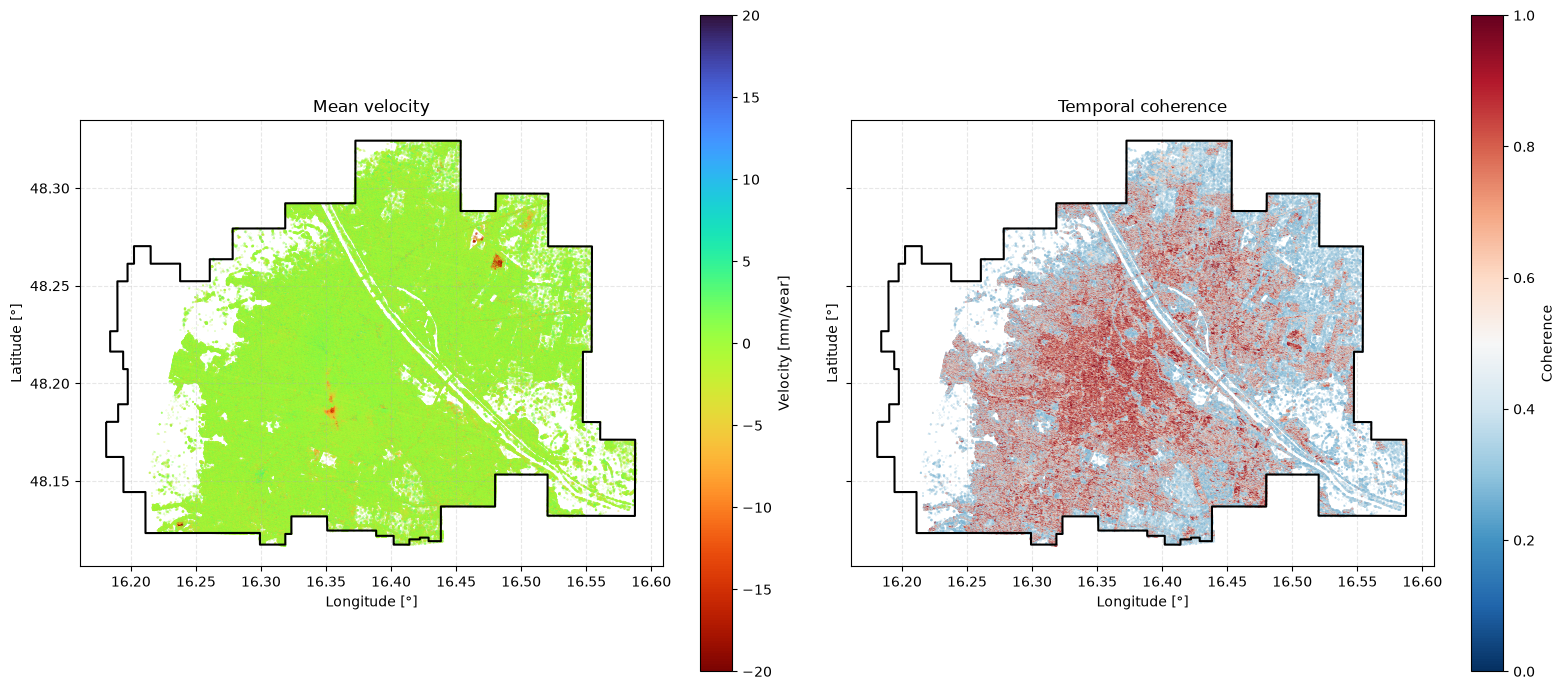

In [29]:
plot_velocity_coherence(
    augmenterra,
    velocity_column="VEL_20220101_20241231",
    coherence_column="COHERENCE",
    vmin=-20,
    vmax=20
)

**EGMS data**

In [23]:
egms.head()

,VEL_20220101_20241231,temporal_coherence,geometry
0,-0.6,0.87,POINT (16.41325 48.11748)
1,-0.6,0.87,POINT (16.41322 48.1175)
2,-0.8,0.96,POINT (16.41322 48.1175)
3,0.8,0.74,POINT (16.41279 48.11754)
4,3.2,0.56,POINT (16.41288 48.11762)


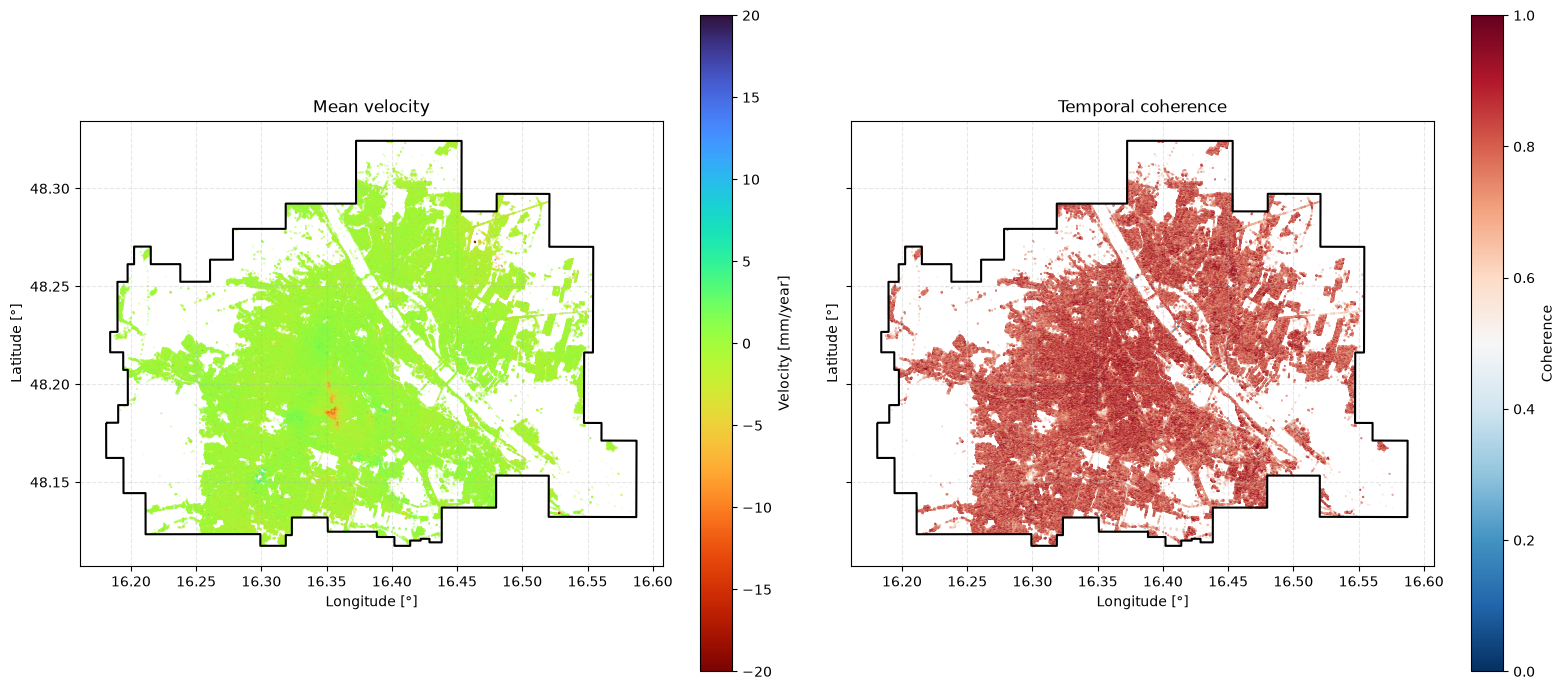

In [30]:
plot_velocity_coherence(
    egms,
    velocity_column="VEL_20220101_20241231",
    coherence_column="temporal_coherence",
    vmin=-20,
    vmax=20
)

**Processed data (ISCE2-Mintpy)**

In [25]:
processed.head()

,VEL,COHERENCE,geometry
0,-18.978948,0.926077,POINT (16.52671 48.13625)
1,-15.369507,0.906998,POINT (16.52123 48.13585)
2,-17.103702,0.941122,POINT (16.52144 48.13587)
3,-12.957951,0.927838,POINT (16.52165 48.13589)
4,9.817093,0.943345,POINT (16.52186 48.13592)


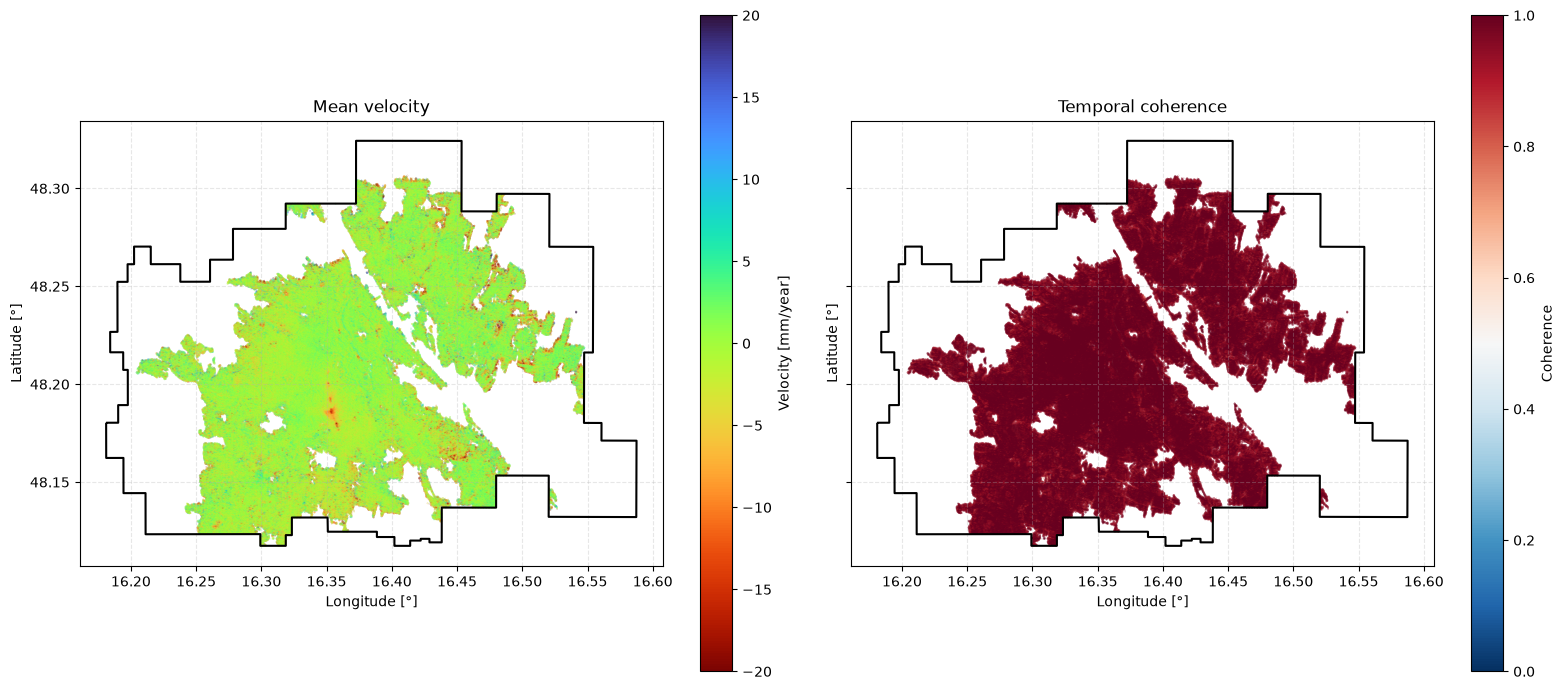

In [31]:
plot_velocity_coherence(
    processed,
    velocity_column="VEL",
    coherence_column="COHERENCE",
    vmin=-20,
    vmax=20
)

# Metrices

## Number of points of each data set

In [32]:
point_counts = {
    "Augmenterra": len(augmenterra),
    "EGMS": len(egms),
    "Own processing": len(processed)
}

for name, count in point_counts.items():
    print(f"{name:16s}: {count:,} points")

Augmenterra     : 2,924,926 points
EGMS            : 1,252,938 points
Own processing  : 546,261 points


## Correlation, RMSE, MAE of mean velocities 

The validation approach follows following steps:
- define a regular grid over the AOI (40m spacing)
- calculate mean velocities within these grid cells for all data sets
- calculate metrices between pairs of datasets
    - e.g. Augmenterra vs EGMS, Augmenterra vs Processed, EGMS vs Processed
    - just pairs where both datasets have data can be plotted!
    - also calculate number of grid cells that can not be compared! (should be minimized)



### Define a regular grid

In [38]:
#  AOI is currently EPSG:4326
print("AOI city CRS:", aoi_city.crs)
aoi_city = aoi_city.to_crs("EPSG:31256")
print("AOI city CRS after transformation:", aoi_city.crs)

AOI city CRS: EPSG:31256
AOI city CRS after transformation: EPSG:31256


Create a grid using the bbox of the aoi_city

In [46]:
grid_size = 40  # metres

xmin, ymin, xmax, ymax = aoi_city.total_bounds

x_coords = np.arange(xmin, xmax, grid_size)
y_coords = np.arange(ymin, ymax, grid_size)

grid_cells = []

for x in x_coords:
    for y in y_coords:
        grid_cells.append(
            box(
                x,
                y,
                x + grid_size,
                y + grid_size
            )
        )

grid = gpd.GeoDataFrame(
    {"geometry": grid_cells},
    crs="EPSG:31256"
)

print(f"Grid cells before clipping: {len(grid):,}")

Grid cells before clipping: 435,456


Clip the grid to the aoi_city

In [47]:
aoi_geometry = aoi_city.union_all()

grid = grid[
    grid.geometry.within(aoi_geometry)
].copy()

grid = grid.reset_index(drop=True)
grid["grid_id"] = np.arange(len(grid))


print(f"Grid cells after clipping: {len(grid):,}")

Grid cells after clipping: 301,511


Check the grid visually

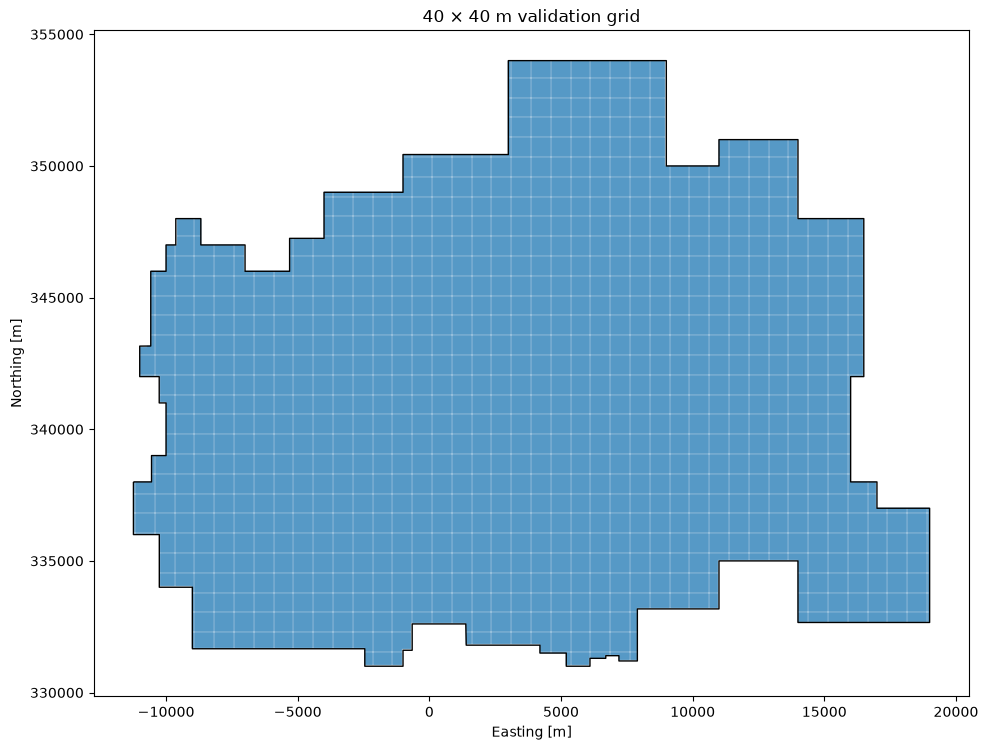

In [48]:
fig, ax = plt.subplots(figsize=(10, 10))

grid.boundary.plot(
    ax=ax,
    linewidth=0.2
)

aoi_city.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

ax.set_aspect("equal")
ax.set_title("40 × 40 m validation grid")
ax.set_xlabel("Easting [m]")
ax.set_ylabel("Northing [m]")

plt.tight_layout()
plt.show()

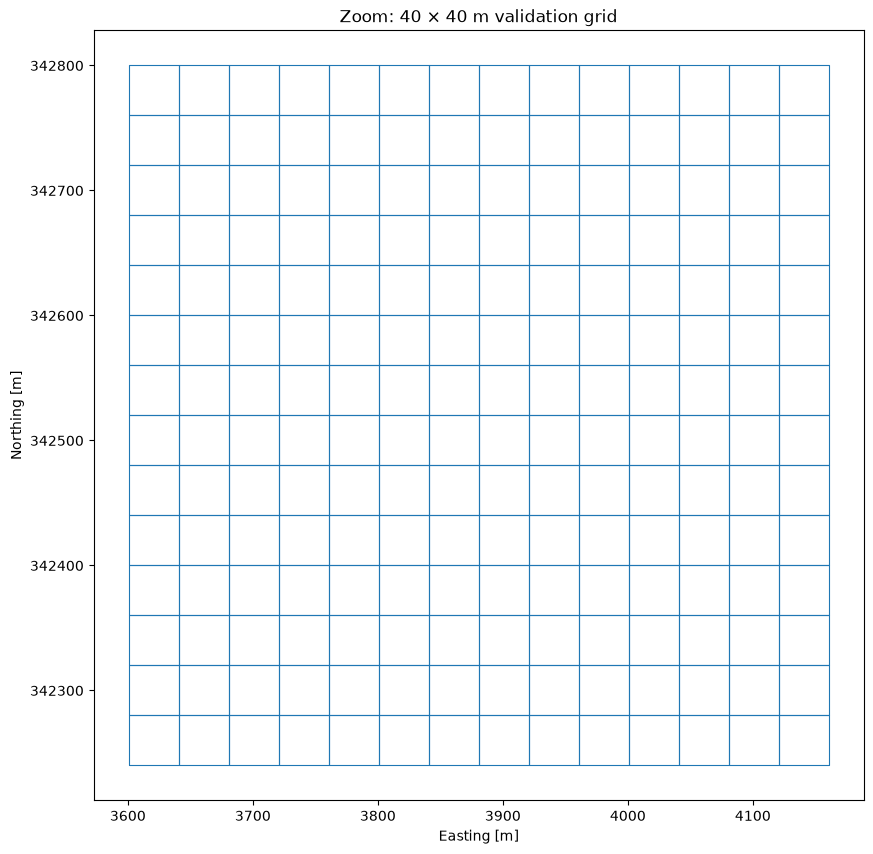

In [49]:
xmin, ymin, xmax, ymax = grid.total_bounds

# Take a small 500 x 500 m area near the centre
cx = (xmin + xmax) / 2
cy = (ymin + ymax) / 2

zoom = grid.cx[
    cx - 250:cx + 250,
    cy - 250:cy + 250
]

zoom = grid.cx[
    cx - 250:cx + 250,
    cy - 250:cy + 250
]

fig, ax = plt.subplots(figsize=(10, 10))

zoom.boundary.plot(
    ax=ax,
    linewidth=0.8
)

ax.set_aspect("equal")
ax.set_title("Zoom: 40 × 40 m validation grid")
ax.set_xlabel("Easting [m]")
ax.set_ylabel("Northing [m]")

plt.show()

In [50]:
width = grid.geometry.bounds["maxx"] - grid.geometry.bounds["minx"]
height = grid.geometry.bounds["maxy"] - grid.geometry.bounds["miny"]

print("Number of cells:", f"{len(grid):,}")
print("Cell widths:", width.unique())
print("Cell heights:", height.unique())

Number of cells: 301,511
Cell widths: [40. 40.]
Cell heights: [40.]


Give each cell a permanent ID

In [51]:
grid["grid_id"] = np.arange(len(grid))

### Transform data sets to EPSG: 31256

In [54]:
target_crs = "EPSG:31256"

augmenterra_31256 = augmenterra.to_crs(target_crs)
egms_31256 = egms.to_crs(target_crs)
processed_31256 = processed.to_crs(target_crs)

In [55]:
print("Augmenterra:", augmenterra_31256.crs)
print("EGMS:       ", egms_31256.crs)
print("Processed:  ", processed_31256.crs)
print("Grid:       ", grid.crs)

Augmenterra: EPSG:31256
EGMS:        EPSG:31256
Processed:   EPSG:31256
Grid:        EPSG:31256


In [56]:
print(augmenterra_31256.geometry.geom_type.value_counts())
print(egms_31256.geometry.geom_type.value_counts())
print(processed_31256.geometry.geom_type.value_counts())

Point    2924926
Name: count, dtype: int64
Point    1252938
Name: count, dtype: int64
Point    546261
Name: count, dtype: int64


### Assign each point to a grid id

In [57]:
augmenterra_grid = gpd.sjoin(
    augmenterra_31256,
    grid[["grid_id", "geometry"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"])

egms_grid = gpd.sjoin(
    egms_31256,
    grid[["grid_id", "geometry"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"])

processed_grid = gpd.sjoin(
    processed_31256,
    grid[["grid_id", "geometry"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"])

Check how many points were assigned to a grid cell

In [58]:
def check_grid_assignment(gdf, name):
    assigned = gdf["grid_id"].notna().sum()
    unassigned = gdf["grid_id"].isna().sum()
    total = len(gdf)

    print(f"{name}")
    print(f"  Total points:     {total:,}")
    print(f"  Assigned:         {assigned:,} ({assigned/total*100:.2f}%)")
    print(f"  Not assigned:     {unassigned:,} ({unassigned/total*100:.2f}%)")
    print()

check_grid_assignment(augmenterra_grid, "Augmenterra")
check_grid_assignment(egms_grid, "EGMS")
check_grid_assignment(processed_grid, "Processed")

Augmenterra
  Total points:     2,924,926
  Assigned:         2,911,061 (99.53%)
  Not assigned:     13,865 (0.47%)

EGMS
  Total points:     1,252,938
  Assigned:         1,250,268 (99.79%)
  Not assigned:     2,670 (0.21%)

Processed
  Total points:     546,261
  Assigned:         545,088 (99.79%)
  Not assigned:     1,173 (0.21%)



Check how many grid cells were occupied by each dataset

Check statistics how many points are typically within one raster cell (just take the filled ones into account)

In [67]:
total_grid_cells = len(grid)

coverage_results = []

for name, gdf in [
    ("Augmenterra", augmenterra_grid),
    ("EGMS", egms_grid),
    ("Processed", processed_grid)
]:
    # Number of points in each occupied grid cell
    counts = gdf["grid_id"].dropna().value_counts()

    occupied = counts.size
    empty = total_grid_cells - occupied
    coverage = occupied / total_grid_cells * 100

    coverage_results.append({
        "dataset": name,
        "total_grid_cells": total_grid_cells,
        "occupied_grid_cells": occupied,
        "empty_grid_cells": empty,
        "coverage_percent": coverage,
        "empty_percent": 100 - coverage,

        # Point density per occupied grid cell
        "mean_points_per_cell": counts.mean(),
        "median_points_per_cell": counts.median(),
        "max_points_per_cell": counts.max()
    })

coverage_df = pd.DataFrame(coverage_results)

coverage_df

,dataset,total_grid_cells,occupied_grid_cells,empty_grid_cells,coverage_percent,empty_percent,mean_points_per_cell,median_points_per_cell,max_points_per_cell
0,Augmenterra,301511,207586,93925,68.848566,31.151434,14.023398,15.0,88
1,EGMS,301511,142869,158642,47.384341,52.615659,8.751150,7.0,91
2,Processed,301511,156142,145369,51.786502,48.213498,3.490976,3.0,9


Mean, Median and Max values just describe statistics of occupied cells!

### Calculate velocity statistics within each grid cell

In [ ]:
# define velocity column names for each dataset
velocity_columns = {
    "Augmenterra": "VEL_20220101_20241231",
    "EGMS": "VEL_20220101_20241231",
    "Processed": "VEL"
}

Function that calculates velocity statistics

In [69]:
def calculate_velocity_statistics(gdf, velocity_column):
    stats = (
        gdf
        .dropna(subset=["grid_id", velocity_column])
        .groupby("grid_id")[velocity_column]
        .agg(
            mean_velocity="mean",
            median_velocity="median",
            std_velocity="std",
            n_points="count"
        )
        .reset_index()
    )

    return stats

Calculate statistics

In [70]:
augmenterra_velocity_stats = calculate_velocity_statistics(
    augmenterra_grid,
    "VEL_20220101_20241231"
)

egms_velocity_stats = calculate_velocity_statistics(
    egms_grid,
    "VEL_20220101_20241231"
)

processed_velocity_stats = calculate_velocity_statistics(
    processed_grid,
    "VEL"
)

Add grid geometry

In [73]:
augmenterra_velocity_stats = grid[
    ["grid_id", "geometry"]
].merge(
    augmenterra_velocity_stats,
    on="grid_id",
    how="left"
)

egms_velocity_stats = grid[
    ["grid_id", "geometry"]
].merge(
    egms_velocity_stats,
    on="grid_id",
    how="left"
)

processed_velocity_stats = grid[
    ["grid_id", "geometry"]
].merge(
    processed_velocity_stats,
    on="grid_id",
    how="left"
)

Convert them to GeoDataFrames

In [75]:
augmenterra_velocity_stats = gpd.GeoDataFrame(
    augmenterra_velocity_stats,
    geometry="geometry",
    crs=grid.crs
)

egms_velocity_stats = gpd.GeoDataFrame(
    egms_velocity_stats,
    geometry="geometry",
    crs=grid.crs
)

processed_velocity_stats = gpd.GeoDataFrame(
    processed_velocity_stats,
    geometry="geometry",
    crs=grid.crs
)

Merge pairwise

In [81]:
aug_proc = augmenterra_velocity_stats[
    ["grid_id", "mean_velocity", "std_velocity", "n_points"]
].merge(
    processed_velocity_stats[
        ["grid_id", "mean_velocity", "std_velocity", "n_points"]
    ],
    on="grid_id",
    suffixes=("_aug", "_egms")
)

Then only keep cells where both datasets have a velocity

In [82]:
aug_proc = aug_proc.dropna(
    subset=["mean_velocity_aug", "mean_velocity_egms"]
)

In [83]:
print(f"Comparable grid cells: {len(aug_proc):,}")

Comparable grid cells: 150,485


### Visualization - Comparison mean velocities in grid cells

In [108]:
def plot_velocity_comparison(
    dataset_1,
    dataset_2,
    name_1,
    name_2,
    figsize=(9, 9)
):
    """
    Compare mean velocities of two gridded datasets.

    Each dataset must contain:
        grid_id
        mean_velocity
        std_velocity
        n_points
    """

    # --------------------------------------------------
    # 1. Merge the two datasets by grid_id
    # --------------------------------------------------

    comparison = dataset_1[
        ["grid_id", "mean_velocity", "std_velocity", "n_points"]
    ].merge(
        dataset_2[
            ["grid_id", "mean_velocity", "std_velocity", "n_points"]
        ],
        on="grid_id",
        suffixes=("_1", "_2")
    )

    # --------------------------------------------------
    # 2. Keep only cells where both datasets have velocity
    # --------------------------------------------------

    comparison = comparison.dropna(
        subset=["mean_velocity_1", "mean_velocity_2"]
    )

    print(
        f"Comparable grid cells: "
        f"{len(comparison):,}"
    )

    # --------------------------------------------------
    # 3. Calculate comparison statistics
    # --------------------------------------------------

    difference = (
        comparison["mean_velocity_1"]
        - comparison["mean_velocity_2"]
    )

    bias = difference.mean()
    mae = difference.abs().mean()
    rmse = np.sqrt((difference ** 2).mean())
    std_difference = difference.std()

    correlation = comparison[
        ["mean_velocity_1", "mean_velocity_2"]
    ].corr().iloc[0, 1]

    # --------------------------------------------------
    # 4. Create scatter plot
    # --------------------------------------------------

    fig, ax = plt.subplots(figsize=figsize)

    ax.errorbar(
        comparison["mean_velocity_1"],
        comparison["mean_velocity_2"],
        #xerr=comparison["std_velocity_1"],
        #yerr=comparison["std_velocity_2"],
        fmt="o",
        markersize=3,
        alpha=0.35,
        elinewidth=0.5,
        capsize=1
    )

    # --------------------------------------------------
    # 5. 1:1 line
    # --------------------------------------------------

    vmin = min(
        comparison["mean_velocity_1"].min(),
        comparison["mean_velocity_2"].min()
    )

    vmax = max(
        comparison["mean_velocity_1"].max(),
        comparison["mean_velocity_2"].max()
    )

    ax.plot(
        [vmin, vmax],
        [vmin, vmax],
        linestyle="--",
        linewidth=1.5,
        label="1:1"
    )

    # --------------------------------------------------
    # 6. Labels
    # --------------------------------------------------

    ax.set_xlabel(
        f"{name_1} mean velocity [mm/year]"
    )

    ax.set_ylabel(
        f"{name_2} mean velocity [mm/year]"
    )

    ax.set_title(
        f"{name_1} vs {name_2}"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    # --------------------------------------------------
    # 7. Add statistics to plot
    # --------------------------------------------------

    stats_text = (
        f"N = {len(comparison):,}\n"
        f"Bias = {bias:.2f} mm/year\n"
        f"MAE = {mae:.2f} mm/year\n"
        f"RMSE = {rmse:.2f} mm/year\n"
        f"Std. diff. = {std_difference:.2f} mm/year\n"
        f"Pearson r = {correlation:.3f}"
    )

    ax.text(
        0.03,
        0.97,
        stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # 8. Return comparison data + statistics
    # --------------------------------------------------

    statistics = {
        "dataset_1": name_1,
        "dataset_2": name_2,
        "comparable_cells": len(comparison),
        "bias": bias,
        "MAE": mae,
        "RMSE": rmse,
        "std_difference": std_difference,
        "pearson_r": correlation
    }

    return comparison, statistics

Comparable grid cells: 129,557


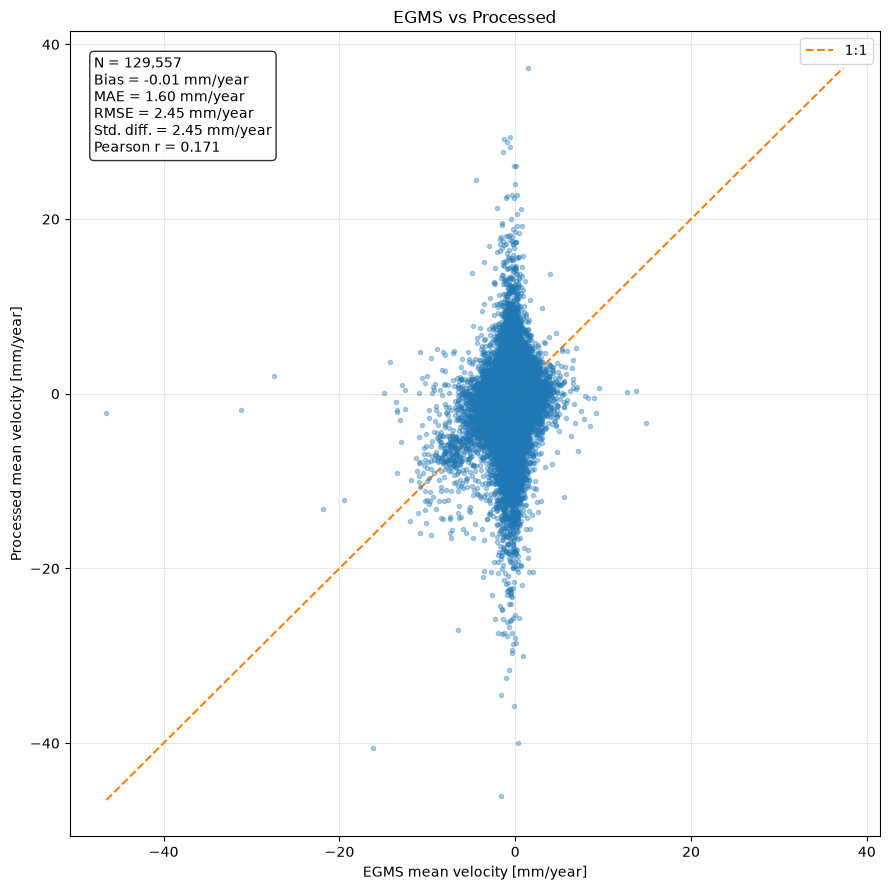

In [109]:
egms_proc, stats_egms_proc = plot_velocity_comparison(
    egms_velocity_stats,
    processed_velocity_stats,
    "EGMS",
    "Processed"
)

Comparable grid cells: 140,408


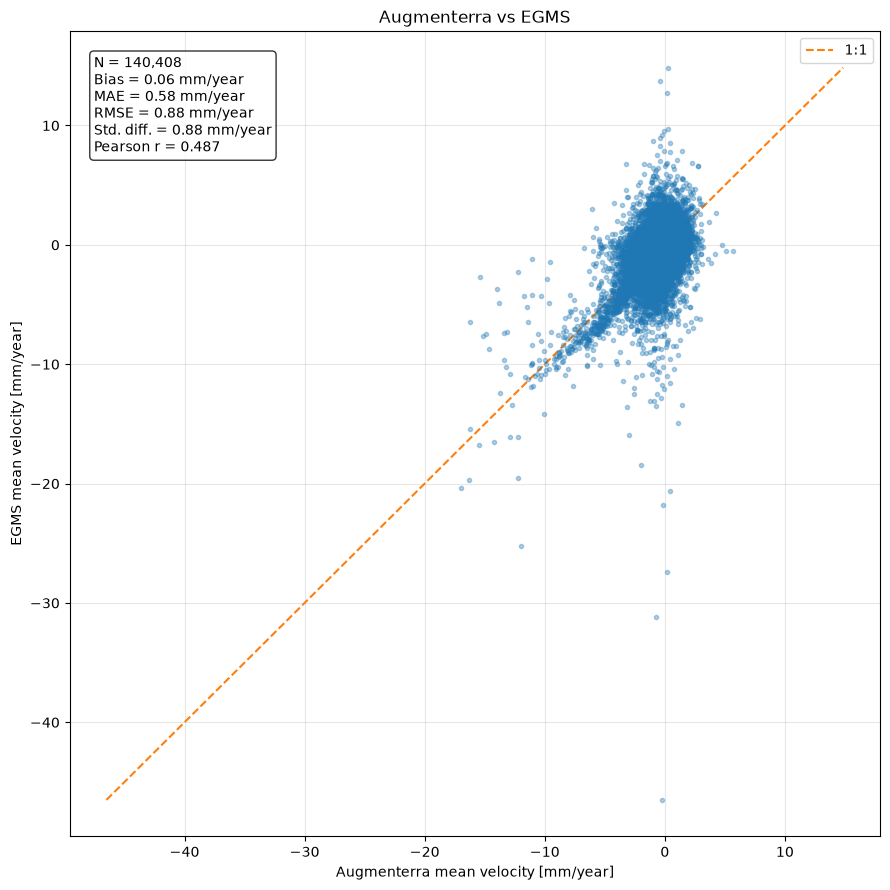

In [110]:
augm_egms, stats_augm_egms = plot_velocity_comparison(
    augmenterra_velocity_stats,
    egms_velocity_stats,
    "Augmenterra",
    "EGMS"
)

In [92]:
augm_egms.head()

,grid_id,mean_velocity_1,std_velocity_1,n_points_1,mean_velocity_2,std_velocity_2,n_points_2
16089,16089,-0.050000,1.228821,4.0,0.285714,0.651738,7.0
16469,16469,0.057143,0.479086,7.0,0.100000,NaN,1.0
16470,16470,-0.468750,1.941037,16.0,0.054545,1.029916,11.0
16471,16471,0.090909,1.206196,11.0,-0.300000,0.655744,3.0
16473,16473,-0.476923,0.597430,13.0,-0.350000,0.789213,8.0


Comparable grid cells: 150,485


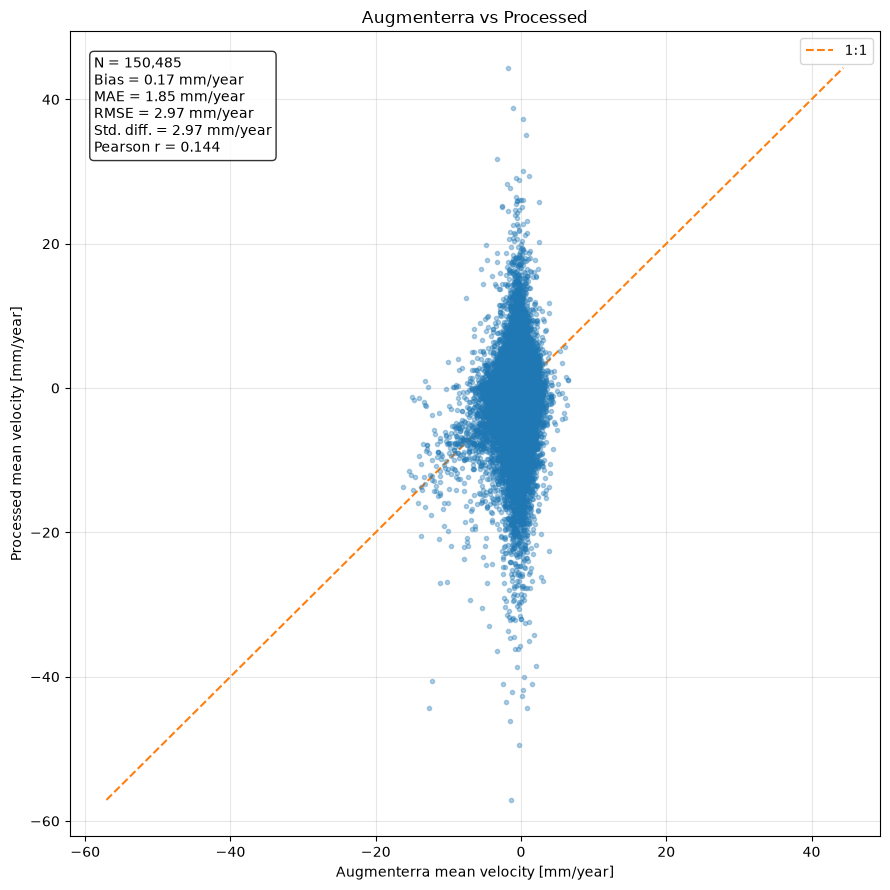

In [111]:
augm_proc, stats_augm_proc = plot_velocity_comparison(
    augmenterra_velocity_stats,
    processed_velocity_stats,
    "Augmenterra",
    "Processed"
)

### Differences in mean velocities

In [95]:
augm_proc.head()

,grid_id,mean_velocity_1,std_velocity_1,n_points_1,mean_velocity_2,std_velocity_2,n_points_2
27009,27009,-3.300000,4.808326,2.0,-0.435672,1.394023,3.0
27010,27010,-1.600000,1.414214,2.0,-2.463908,3.414985,3.0
27011,27011,-0.500000,0.141421,4.0,-3.525907,2.125687,3.0
27012,27012,-2.000000,0.141421,2.0,-1.133970,0.658932,3.0
27013,27013,-0.433333,2.816144,6.0,0.462897,3.174020,3.0


In [96]:
augm_proc["velocity_difference"] = (
    augm_proc["mean_velocity_1"]
    - augm_proc["mean_velocity_2"]
)

In [97]:
augm_proc_map = grid[["grid_id", "geometry"]].merge(
    augm_proc,
    on="grid_id",
    how="inner"
)

augm_proc_map = gpd.GeoDataFrame(
    augm_proc_map,
    geometry="geometry",
    crs=grid.crs
)

In [98]:
augm_proc_map

,grid_id,geometry,mean_velocity_1,std_velocity_1,n_points_1,mean_velocity_2,std_velocity_2,n_points_2,velocity_difference
0,27009,"POLYGON ((-7479.391 340920.001, -7479.391 3409...",-3.300000,4.808326,2.0,-0.435672,1.394023,3.0,-2.864328
1,27010,"POLYGON ((-7479.391 340960.001, -7479.391 3410...",-1.600000,1.414214,2.0,-2.463908,3.414985,3.0,0.863908
2,27011,"POLYGON ((-7479.391 341000.001, -7479.391 3410...",-0.500000,0.141421,4.0,-3.525907,2.125687,3.0,3.025907
3,27012,"POLYGON ((-7479.391 341040.001, -7479.391 3410...",-2.000000,0.141421,2.0,-1.133970,0.658932,3.0,-0.866030
4,27013,"POLYGON ((-7479.391 341080.001, -7479.391 3411...",-0.433333,2.816144,6.0,0.462897,3.174020,3.0,-0.896231
...,...,...,...,...,...,...,...,...,...
150480,290987,"POLYGON ((16000.609 342240.001, 16000.609 3422...",0.207143,1.911690,14.0,2.943400,3.460198,5.0,-2.736257
150481,290989,"POLYGON ((16000.609 342320.001, 16000.609 3423...",0.791667,1.747444,12.0,5.055223,7.061661,2.0,-4.263556
150482,291267,"POLYGON ((16040.609 342160.001, 16040.609 3422...",-0.666667,0.305505,3.0,15.030627,NaN,1.0,-15.697294
150483,291268,"POLYGON ((16040.609 342200.001, 16040.609 3422...",-2.686667,2.358531,15.0,10.010336,NaN,1.0,-12.697002


vmin = -8.37 mm/year
vmax = 8.37 mm/year


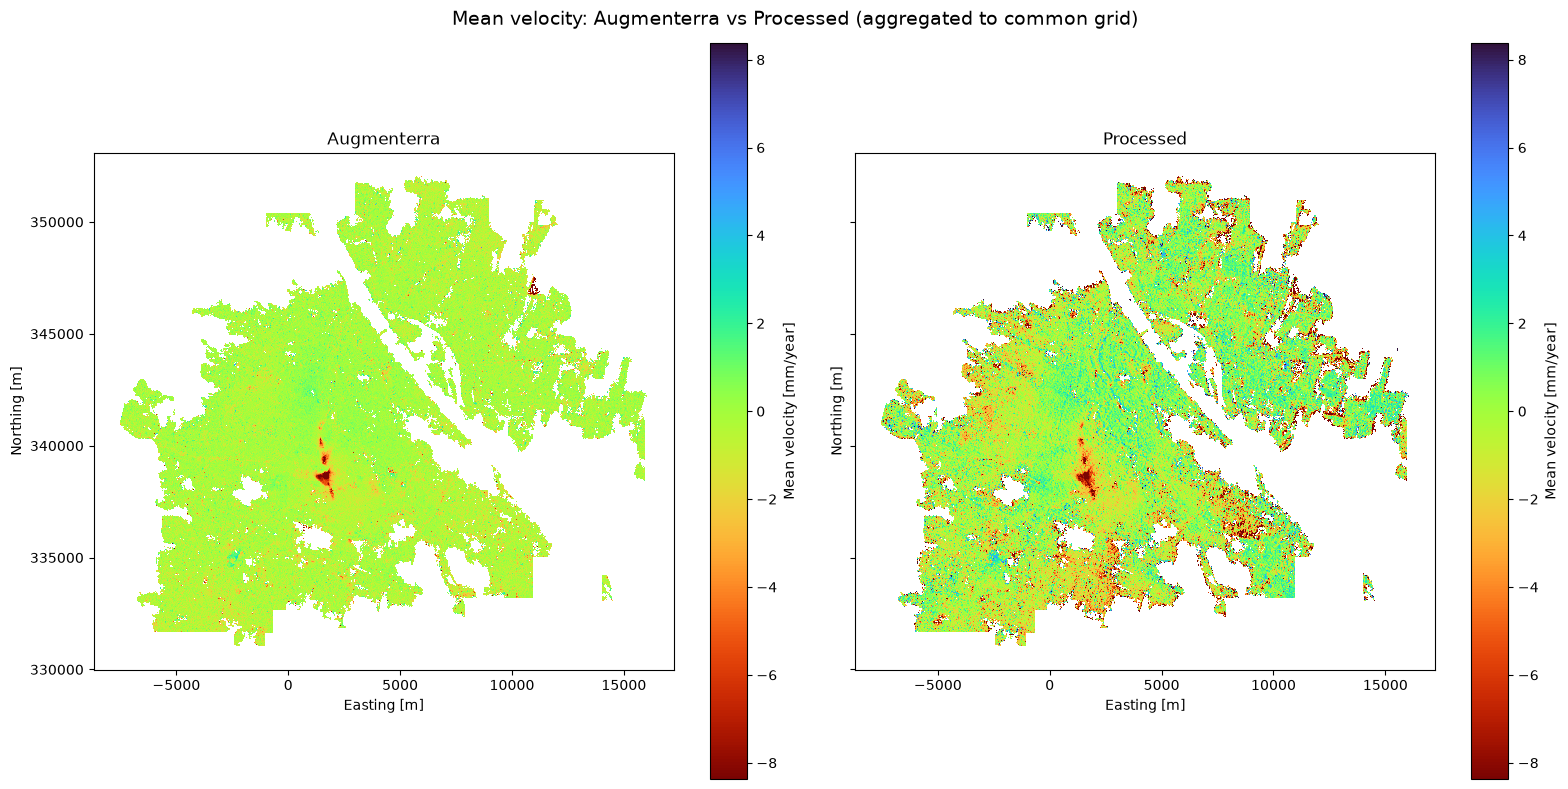

In [104]:
# Same velocity range for both datasets
# Central 98% of the combined velocity distribution
lower = np.percentile(
    np.concatenate([
        augm_proc_map["mean_velocity_1"].dropna().values,
        augm_proc_map["mean_velocity_2"].dropna().values
    ]),
    1
)

upper = np.percentile(
    np.concatenate([
        augm_proc_map["mean_velocity_1"].dropna().values,
        augm_proc_map["mean_velocity_2"].dropna().values
    ]),
    99
)

# Make the range symmetric around zero
limit = max(abs(lower), abs(upper))

vmin = -limit
vmax = limit

print(f"vmin = {vmin:.2f} mm/year")
print(f"vmax = {vmax:.2f} mm/year")


# Plot the mean velocities of Augmenterra and Processed datasets side by side
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    sharex=True,
    sharey=True
)

# Augmenterra
augm_proc_map.plot(
    ax=axes[0],
    column="mean_velocity_1",
    cmap="turbo_r",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    linewidth=0,
    legend_kwds={
        "label": "Mean velocity [mm/year]"
    }
)

axes[0].set_title("Augmenterra")
axes[0].set_xlabel("Easting [m]")
axes[0].set_ylabel("Northing [m]")
axes[0].set_aspect("equal")


# Processed
augm_proc_map.plot(
    ax=axes[1],
    column="mean_velocity_2",
    cmap="turbo_r",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    linewidth=0,
    legend_kwds={
        "label": "Mean velocity [mm/year]"
    }
)

axes[1].set_title("Processed")
axes[1].set_xlabel("Easting [m]")
axes[1].set_ylabel("Northing [m]")
axes[1].set_aspect("equal")


plt.suptitle(
    "Mean velocity: Augmenterra vs Processed (aggregated to common grid)",
    fontsize=14
)

plt.tight_layout()
plt.show()

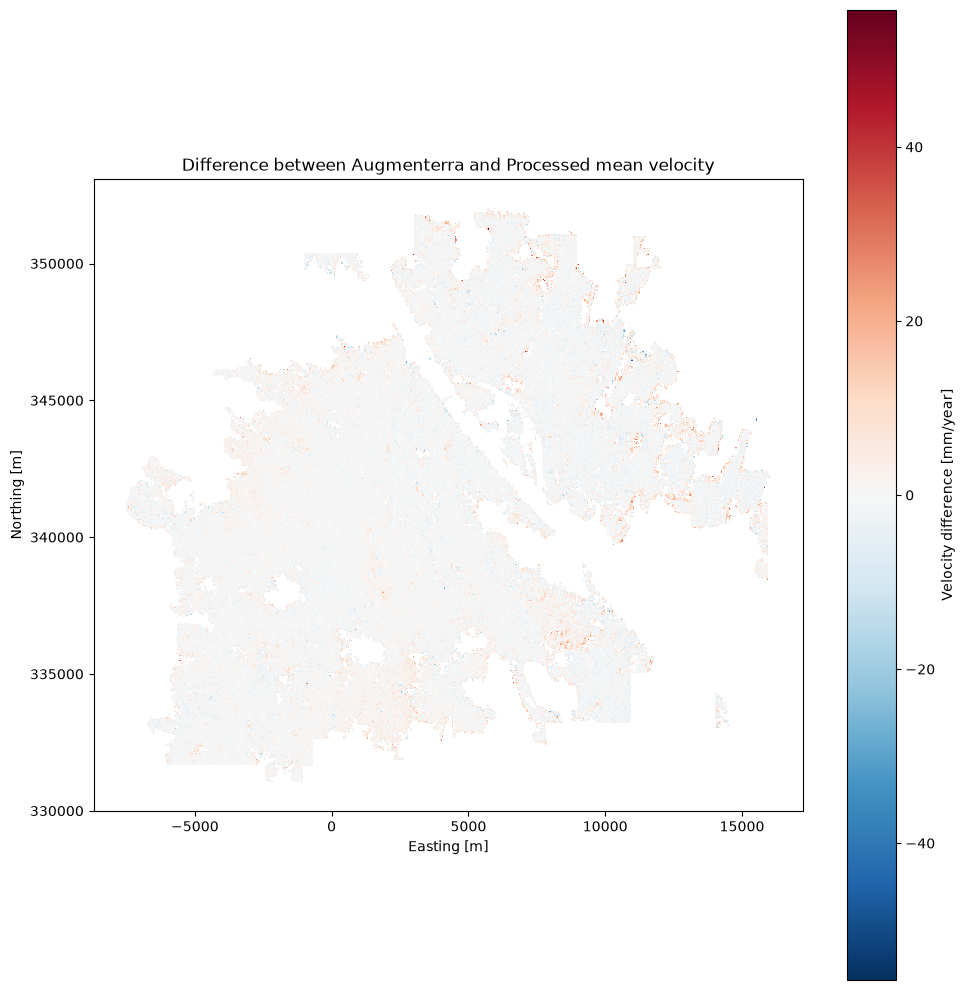

In [105]:
vmax = np.nanmax(
    np.abs(augm_proc_map["velocity_difference"])
)

fig, ax = plt.subplots(figsize=(10, 10))

augm_proc_map.plot(
    ax=ax,
    column="velocity_difference",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    legend=True,
    linewidth=0,
    legend_kwds={
        "label": "Velocity difference [mm/year]"
    }
)

ax.set_title(
    "Difference between Augmenterra and Processed mean velocity"
)

ax.set_xlabel("Easting [m]")
ax.set_ylabel("Northing [m]")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

Positive values: mean velocity of Augmenterra data is higher than mean velocity of processed data 

--> especially at the edges processed data have lower velocities (mainly negative which means subsidence whereas Augmenterra data show values around 0)

## Further Ideas

- Map of point densities (maybe other grid size)
- 